  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Model Evaluation
----------------
Accuracy : 0.9668161434977578
Precision: 1.0
Recall   : 0.7516778523489933
F1 Score : 0.8582375478927203

Classification Report
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



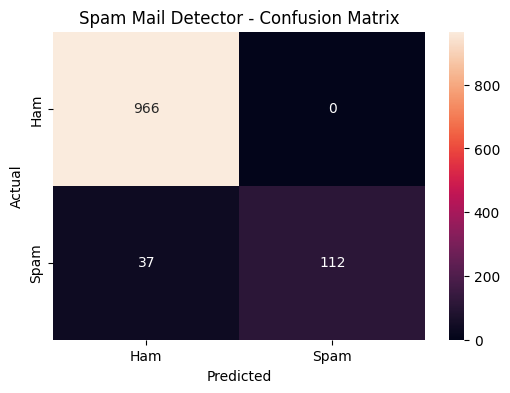


New Message Predictions

Message: Congratulations! You have won a free prize. Claim it now!
Prediction: SPAM

Message: Hey, are you coming to college tomorrow?
Prediction: HAM

Message: URGENT! You have won 10000 dollars. Call now!
Prediction: SPAM

Message: Can you send me the notes from today's class?
Prediction: HAM


In [1]:
import pandas as pd
import numpy as np
import re
import zipfile
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open("SMSSpamCollection") as file:
        data = pd.read_csv(
            file,
            sep="\t",
            header=None,
            names=["label", "message"]
        )


print(data.head())
print("\nDataset Shape:", data.shape)
print("\nClass Distribution:")
print(data["label"].value_counts())


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


data["message"] = data["message"].apply(clean_text)

data["label"] = data["label"].map({
    "ham": 0,
    "spam": 1
})


X = data["message"]
y = data["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


model = MultinomialNB()

model.fit(X_train_tfidf, y_train)


y_pred = model.predict(X_test_tfidf)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("\nModel Evaluation")
print("----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Mail Detector - Confusion Matrix")
plt.show()


test_messages = [
    "Congratulations! You have won a free prize. Claim it now!",
    "Hey, are you coming to college tomorrow?",
    "URGENT! You have won 10000 dollars. Call now!",
    "Can you send me the notes from today's class?"
]


test_cleaned = [clean_text(message) for message in test_messages]

test_features = vectorizer.transform(test_cleaned)

predictions = model.predict(test_features)


print("\nNew Message Predictions")

for message, prediction in zip(test_messages, predictions):
    result = "SPAM" if prediction == 1 else "HAM"
    print("\nMessage:", message)
    print("Prediction:", result)